In [1]:
# Forward-model tests: pentagon scaffold, InfoMW horns

#Each test is: **build** a case, **plot** its geometry, **run** it, **plot** its S-parameters.

#- Run cells 2–5 once (imports, parameters, functions).
#- A Meep simulation can only be run once. To rerun a test, rerun its **build** cell first, then its **run** cell.
#- Results are saved to `results/<test name>_src<k>.npz`, so plots can be redone later without simulating.

In [2]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import meep as mp
import meep.adjoint as mpa
import autograd.numpy as npa #numpy that the adjoint solver can differentiate
from plasmeep.lib import Plasmeep as pm, WP
from scipy.special import j0, jn_zeros
from scipy.optimize import brentq

results_dir = os.path.join(os.getcwd(), "results")
os.makedirs(results_dir, exist_ok=True)

Using MPI version 4.1, 1 processes


In [3]:
# ***Parameters shared by every test***

# Units and domain
a = 0.01 # meters
res = 20 # pixels per a
dpml = 5.0 # PML thickness in units of a
nx = 52 # cell size in units of a, PML included
ny = 52

# Plasma and scaffold geometry
R_p = 1.5 #plasma radius
r_in = 2.0 #vacuum hole around the plasma

# Horn dimensions (InversePMMDesign Add_INFOMW_Horn, TM orientation)
# Lab horn sizes in meters, converted to units of a.
n_ports = 5
wall_t = 0.004/a #wall thickness
width_open = 0.104/a #outer width at the aperture
width_base = 0.048/a #outer width at the throat / feed waveguide
depth = 0.089/a #flare length, aperture to throat
w_feed_in = width_base - 2*wall_t #inner width of the feed waveguide

# Pentagon: one horn aperture per side, so the side length is the aperture width.
side = width_open
apothem = side/(2*np.tan(np.pi/n_ports)) #center to middle of a side
R_pent = side/(2*np.sin(np.pi/n_ports)) #center to a vertex

# Side k faces theta_k = k*72 deg. Pentagon vertices sit halfway between.
port_thetas = [k*2*np.pi/n_ports for k in range(n_ports)]

# Each feed guide runs straight out until it is dpml/2 deep in the PML.
h_end = nx/2 - dpml/2
r_throat = apothem + depth #flare-to-feed junction, measured from the center

# Probe band in MEEP frequency units (f = 1 <-> 30 GHz at a = 1 cm).
# Feed cutoff: f = 1/(2*w_feed_in) = 0.125 (3.75 GHz). Second feed mode above 0.25 (7.5 GHz).
f_min = 0.14
f_max = 0.3
fcen = 0.5*(f_min + f_max)
df = f_max - f_min
n_freq = 41
freqs = np.linspace(f_min, f_max, n_freq) #frequencies the monitors record
fc_feed = 1/(2*w_feed_in) #cutoff of the fundamental feed-guide mode
f_2nd = 2*fc_feed #second feed mode turns on here (0.25)

# Source and monitor positions in the straight feed, measured back from the throat.
d_src = 3.0 #source, a behind the throat
d_mon = 1.0 #port monitors, a behind the throat

In [4]:
# ***Functions: horns, source line, tilted ports, plasma, S-parameters***

def add_infomw_horn(model, open_cen, horn_dir, entrance_length,
                    wall_t=0.4, width_open=10.4, width_base=4.8, depth=8.9):
    """Metal horn walls, ported from InversePMMDesign PMMI.Add_INFOMW_Horn.

    All lengths are in units of a. open_cen: (x, y) center of the aperture.
    horn_dir: unit vector out of the aperture, toward the device.
    entrance_length: length of the straight feed waveguide behind the flare.
    Appends four PEC prisms to model.geometry: two flared walls, two feed walls.
    """
    cx, cy = float(open_cen[0]), float(open_cen[1])
    dx, dy = float(horn_dir[0]), float(horn_dir[1])
    ox, oy = dy, -dx #unit vector across the horn
    back = depth + entrance_length

    def pt(across, along):
        #point at 'across' from the horn axis and 'along' behind the aperture
        return mp.Vector3(cx + across*ox - along*dx, cy + across*oy - along*dy, 0)

    for sgn in (1, -1):
        flare = [
            pt(sgn*width_open/2, 0),
            pt(sgn*(width_open/2 - wall_t), 0),
            pt(sgn*(width_base/2 - wall_t), depth),
            pt(sgn*width_base/2, depth),
        ]
        feed = [
            pt(sgn*(width_base/2 - wall_t), depth),
            pt(sgn*width_base/2, depth),
            pt(sgn*width_base/2, back),
            pt(sgn*(width_base/2 - wall_t), back),
        ]
        for verts in (flare, feed):
            model.geometry.append(
                mp.Prism(vertices=verts, height=mp.inf, axis=mp.Vector3(0, 0, 1),
                         material=mp.perfect_electric_conductor))

def feed_line(theta, r, margin=2.0/res):
    """Axis-aligned line across a horn's feed guide at radius r (for the source).
    Returns (center, size, k_out); k_out points away from the device."""
    c, s = float(np.cos(theta)), float(np.sin(theta))
    span = (w_feed_in - 2*margin)/max(abs(c), abs(s))
    size = mp.Vector3(0, span, 0) if abs(c) >= abs(s) else mp.Vector3(span, 0, 0)
    return mp.Vector3(r*c, r*s, 0), size, mp.Vector3(c, s, 0)

def bilinear_matrix(xs, ys, pts):
    """Matrix W so that (W @ F.ravel()) interpolates grid values F[ix, iy]
    at the points pts (N x 2), bilinearly."""
    nxs, nys = len(xs), len(ys)
    W = np.zeros((len(pts), nxs*nys))
    for p, (px, py) in enumerate(pts):
        i = int(np.clip(np.searchsorted(xs, px) - 1, 0, nxs - 2))
        j = int(np.clip(np.searchsorted(ys, py) - 1, 0, nys - 2))
        tx = (px - xs[i])/(xs[i+1] - xs[i])
        ty = (py - ys[j])/(ys[j+1] - ys[j])
        for di, dj, wt in ((0, 0, (1-tx)*(1-ty)), (1, 0, tx*(1-ty)),
                           (0, 1, (1-tx)*ty), (1, 1, tx*ty)):
            W[p, (i+di)*nys + (j+dj)] = wt
    return W

class TiltedPort:
    """Raw-field monitor on a line across a feed guide, at the horn's angle.

    n: outward unit normal (along the horn axis, away from the device)
    t: unit vector along the line, across the guide (t = z x n)
    u: positions along the line, -w/2..w/2, with trapezoid weights du
    """
    def __init__(self, sim, theta, r, pad=3.0/res):
        c, s = float(np.cos(theta)), float(np.sin(theta))
        self.sim = sim
        self.theta = theta
        self.n = np.array([c, s])
        self.t = np.array([-s, c])
        self.center = r*self.n
        n_pts = int(np.ceil(2*res*w_feed_in)) + 1 #half-pixel spacing
        self.u = np.linspace(-w_feed_in/2, w_feed_in/2, n_pts)
        self.du = np.full(n_pts, self.u[1] - self.u[0])
        self.du[[0, -1]] *= 0.5
        self.pts = self.center[None, :] + self.u[:, None]*self.t[None, :]
        lo = self.pts.min(axis=0) - pad
        hi = self.pts.max(axis=0) + pad
        self.box = mp.Volume(center=mp.Vector3(*(0.5*(lo + hi))),
                             size=mp.Vector3(*(hi - lo)))
        self.fields = [mpa.FourierFields(sim, self.box, comp) #voxel-centered
                       for comp in (mp.Ez, mp.Hx, mp.Hy)]
        self.W = None

    def register_monitors(self, frequencies):
        #Not needed inside mpa.OptimizationProblem, which registers them itself.
        for ff in self.fields:
            ff.register_monitors(frequencies)

    def _build_interp(self):
        #Grid coordinates of the DFT arrays; available once the monitor exists.
        xs, ys, _, _ = self.sim.get_array_metadata(dft_cell=self.fields[0]._monitor)
        self.W = bilinear_matrix(np.asarray(xs), np.asarray(ys), self.pts)

    def line_fields(self, Ez, Hx, Hy):
        """Ez and H_t (H along t) on the tilted line, shape (n_freq, n_pts)."""
        if self.W is None:
            self._build_interp()
        nf = Ez.shape[0]
        interp = lambda F: npa.dot(npa.reshape(F, (nf, -1)), self.W.T)
        return interp(Ez), interp(Hx)*self.t[0] + interp(Hy)*self.t[1]

def port_flux(port, Ez_l, Ht_l):
    """Net Poynting power out through the line (away from the device)."""
    return -0.5*npa.real(npa.sum(Ez_l*npa.conj(Ht_l)*port.du, axis=1))

def port_modes(port, Ez_l, Ht_l, freqs):
    """Complex amplitudes (c_out, c_in) of the fundamental mode cos(pi*u/w)."""
    m = np.cos(np.pi*port.u/w_feed_in)
    norm = np.sum(m*m*port.du)
    A = npa.sum(Ez_l*m*port.du, axis=1)/norm
    B = npa.sum(Ht_l*m*port.du, axis=1)/norm
    omega_over_beta = 1/np.sqrt(1 - (fc_feed/np.asarray(freqs))**2)
    return 0.5*(A - omega_over_beta*B), 0.5*(A + omega_over_beta*B)

def mode_power(port, c, freqs):
    """Power carried by mode amplitude c: 0.5 (beta/omega) |c|^2 int m^2 du."""
    m = np.cos(np.pi*port.u/w_feed_in)
    beta_over_omega = np.sqrt(1 - (fc_feed/np.asarray(freqs))**2)
    return 0.5*beta_over_omega*npa.abs(c)**2*np.sum(m*m*port.du)

BETA_SCHOTTKY = jn_zeros(0, 1)[0]

def bessel_profile(r, n0, beta, R_p):
    """n_e(r) = n0*J0(beta*r/R_p)."""
    return n0*j0(beta*r/R_p)

def beta_from_h(h):
    #h = J0(beta) = edge-to-center ratio, beta in (0, 2.405]
    return brentq(lambda b: j0(b) - h, 1e-6, BETA_SCHOTTKY)

def add_plasma(model, n0, h, gamma_Hz=1e9, N_shells=12):
    """Plasma column n_e(r) = n0*J0(beta*r/R_p) as concentric Drude shells.
    Largest shell first; smaller ones paint over it. Returns (r_mid, n) per shell."""
    beta = beta_from_h(h)
    gamma_meep = model.Nondimensionalize_Freq(gamma_Hz)
    shell_r, shell_n = [], []
    for i in range(N_shells, 0, -1):
        r_out = R_p*i/N_shells
        r_mid = R_p*(i - 0.5)/N_shells
        n_i = max(float(bessel_profile(r_mid, n0, beta, R_p)), 1e10)
        wp_meep = model.Nondimensionalize_Freq(WP(n_i)/(2*np.pi))
        model.geometry.append(mp.Cylinder(
            radius=r_out, center=mp.Vector3(0, 0, 0),
            material=model.Get_Med(1.0, wp=wp_meep, gamma=gamma_meep)))
        shell_r.append(r_mid)
        shell_n.append(n_i)
    return np.array(shell_r), np.array(shell_n)

def s_parameters(dft_arrays, ports, k_src):
    """S and T from the raw DFT arrays (Ez_0, Hx_0, Hy_0, Ez_1, ...) of all ports.
      S[k] = c_out,k / c_in,src   (complex mode S-parameters)
      T[k] = P_k / P_inc          (raw-Poynting power ratios)"""
    lines = [ports[k].line_fields(*dft_arrays[3*k:3*k + 3]) for k in range(len(ports))]
    modes = [port_modes(ports[k], *lines[k], freqs) for k in range(len(ports))]
    c_inc = modes[k_src][1]
    S = npa.stack([modes[k][0]/c_inc for k in range(len(ports))])
    #In the source horn the net flux is P_refl - P_inc, so add P_inc back.
    P_inc = mode_power(ports[k_src], c_inc, freqs)
    P = [port_flux(ports[k], *lines[k]) for k in range(len(ports))]
    P[k_src] = P[k_src] + P_inc
    T = npa.stack([P[k]/P_inc for k in range(len(ports))])
    return S, T

In [5]:
# ***Functions: build, plot geometry, run, plot results***

def build_case(k_src=0, scaffold_eps=None, plasma=None):
    """Build one simulation.

    k_src: source horn (0 or 2 for the lab VNA)
    scaffold_eps: None -> no scaffold; a number -> uniform pentagon of that
                  epsilon with the vacuum hole cut out
    plasma: None -> no plasma; a dict like dict(n0=5e16, h=0.4) with optional
            gamma_Hz (default 1e9) and N_shells (default 12)
    """
    model = pm(a, res, dpml, nx, ny)

    if scaffold_eps is not None:
        pent_vertices = [
            mp.Vector3(R_pent*np.cos(t + np.pi/n_ports), R_pent*np.sin(t + np.pi/n_ports), 0)
            for t in port_thetas]
        model.geometry.append(mp.Prism(vertices=pent_vertices, height=mp.inf,
                                       axis=mp.Vector3(0, 0, 1),
                                       material=mp.Medium(epsilon=scaffold_eps)))
        model.geometry.append(mp.Cylinder(radius=r_in, center=mp.Vector3(0, 0, 0),
                                          material=mp.Medium(epsilon=1.0))) #vacuum hole

    shells = None
    if plasma is not None: #after the vacuum hole, or the hole paints over it
        shells = add_plasma(model, **plasma)

    for theta in port_thetas:
        c, s = np.cos(theta), np.sin(theta)
        r_end = h_end/max(abs(c), abs(s))
        add_infomw_horn(model, open_cen=(apothem*c, apothem*s), horn_dir=(-c, -s),
                        entrance_length=r_end - r_throat, wall_t=wall_t,
                        width_open=width_open, width_base=width_base, depth=depth)

    theta_src = port_thetas[k_src]
    src_center, src_size, k_out_src = feed_line(theta_src, r_throat + d_src)
    model.sources = [mp.EigenModeSource(
        src=mp.GaussianSource(frequency=fcen, fwidth=df),
        center=src_center, size=src_size,
        direction=mp.NO_DIRECTION,
        eig_kpoint=k_out_src.scale(-1), #launch toward the device
        eig_band=1,
        eig_parity=mp.ODD_Z, #Ez polarization (TM)
        eig_match_freq=True,
    )]

    sim = model.Get_Sim()
    ports = [TiltedPort(sim, theta, r_throat + d_mon) for theta in port_thetas]
    for p in ports:
        p.register_monitors(freqs)

    return dict(sim=sim, model=model, ports=ports, k_src=k_src,
                scaffold_eps=scaffold_eps, plasma=plasma, shells=shells,
                src_center=src_center, src_size=src_size, has_run=False)

def check_plasma(case, f=None):
    """Compare Meep's complex epsilon at the column center with the Drude formula."""
    if case["plasma"] is None:
        print("no plasma in this case")
        return
    f = fcen if f is None else f
    case["sim"].init_sim()
    eps_c = complex(case["sim"].get_epsilon_point(mp.Vector3(0, 0, 0), frequency=f))
    model = case["model"]
    fp = model.Nondimensionalize_Freq(WP(case["shells"][1][-1])/(2*np.pi))
    g = model.Nondimensionalize_Freq(case["plasma"].get("gamma_Hz", 1e9))
    expected = 1 - fp**2/(f**2 + 1j*g*f)
    print(f"plasma eps at center, {f*30:.2f} GHz: Meep {eps_c:.4f}, expected {expected:.4f}")

def plot_geometry(case, title=""):
    """Permittivity map with metal walls, PML edge, plasma outline, source and ports."""
    sim, ports = case["sim"], case["ports"]
    sim.init_sim()
    eps = np.real(sim.get_array(center=mp.Vector3(), size=sim.cell_size,
                                component=mp.Dielectric))
    metal = ~np.isfinite(eps) | (eps < 0.5) | (eps > 1e3)
    cmap = plt.cm.Blues.copy()
    cmap.set_bad("dimgray") #metal horn walls

    fig, ax = plt.subplots(figsize=(7, 7))
    vmax = max(case["scaffold_eps"] or 1.0, 4.0) #same color scale for every test
    im = ax.imshow(np.ma.masked_where(metal, eps).T, origin="lower",
                   extent=[-nx/2, nx/2, -ny/2, ny/2], cmap=cmap,
                   vmin=1, vmax=vmax, interpolation="nearest")
    fig.colorbar(im, ax=ax, shrink=0.8, label="relative permittivity")
    ax.add_patch(plt.Rectangle((-nx/2 + dpml, -ny/2 + dpml), nx - 2*dpml, ny - 2*dpml,
                               fill=False, color="green", linestyle=":", linewidth=1,
                               label="PML edge"))
    if case["plasma"] is not None:
        ax.add_patch(plt.Circle((0, 0), R_p, fill=False, color="orange",
                                linestyle="-", linewidth=1.5, label="plasma column"))
    else:
        ax.add_patch(plt.Circle((0, 0), R_p, fill=False, color="orange",
                                linestyle="--", linewidth=1.0, label="plasma (not included)"))
    c, z = case["src_center"], case["src_size"]
    ax.plot([c.x - z.x/2, c.x + z.x/2], [c.y - z.y/2, c.y + z.y/2],
            color="red", linewidth=2.5, label=f"source (horn {case['k_src']})")
    for k, p in enumerate(ports):
        ax.plot(p.pts[:, 0], p.pts[:, 1], color="magenta", linewidth=2,
                label="port monitors" if k == 0 else None)
    ax.plot([], [], "s", color="dimgray", label="metal horn walls")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
    ax.set_xlabel("x (a)")
    ax.set_ylabel("y (a)")
    ax.set_title(title)
    plt.show()

def run_case(case, name):
    """Run the simulation, compute S and T, save them, and return the results."""
    if case["has_run"]:
        raise RuntimeError("This case has already run. Rerun its build cell first.")
    case["sim"].run(until_after_sources=mp.stop_when_dft_decayed(tol=1e-6))
    case["has_run"] = True

    dft_arrays = [ff() for p in case["ports"] for ff in p.fields]
    S, T = s_parameters(dft_arrays, case["ports"], case["k_src"])
    pl = case["plasma"] or {}
    result = dict(name=name, freqs=freqs, freqs_GHz=freqs*30, S=S, T=T,
                  port_thetas=np.array(port_thetas), k_src=case["k_src"],
                  scaffold_eps=-1.0 if case["scaffold_eps"] is None else case["scaffold_eps"],
                  n0=pl.get("n0", 0.0), h=pl.get("h", -1.0),
                  gamma_Hz=pl.get("gamma_Hz", 1e9) if pl else 0.0)
    path = os.path.join(results_dir, f"{name}_src{case['k_src']}.npz")
    np.savez(path, **result)
    print("Saved", path)
    return result

def load_result(name, k_src):
    """Load a saved result (to replot without rerunning)."""
    d = np.load(os.path.join(results_dir, f"{name}_src{k_src}.npz"))
    return {key: d[key] for key in d.files}

def plot_S(result, title=""):
    """One panel per horn (mode |S|^2 solid, raw Poynting dotted) plus the energy check."""
    f_GHz, S, T = result["freqs_GHz"], result["S"], result["T"]
    k_src = int(result["k_src"])
    fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)
    axes = axes.ravel()
    for k in range(n_ports):
        ax = axes[k]
        ax.plot(f_GHz, 10*np.log10(np.abs(S[k])**2), "-", color="C0",
                label="mode projection |S|²")
        ax.plot(f_GHz, 10*np.log10(np.abs(T[k])), ":", color="C1", label="raw Poynting")
        ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
        role = "reflection, source horn" if k == k_src else "transmission"
        ax.set_title(f"horn {k} ({np.degrees(port_thetas[k]):.0f}°): S_{k}{k_src}, {role}")
        ax.grid(alpha=0.3)
    ax = axes[n_ports]
    ax.plot(f_GHz, 10*np.log10(np.sum(np.abs(S)**2, axis=0)), "k-")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title("sum of |S|² over all horns (energy check)")
    ax.grid(alpha=0.3)
    for ax in axes[-2:]:
        ax.set_xlabel("frequency (GHz)")
    for ax in axes[::2]:
        ax.set_ylabel("power fraction (dB)")
    axes[0].legend(loc="lower left", fontsize=8)
    fig.suptitle(title or f"{result['name']}, drive from horn {k_src}")
    fig.tight_layout()
    plt.show()

def summarize(result):
    """Numbers for the checks, using only the single-mode band (below 7.5 GHz)."""
    f, S, T = result["freqs"], result["S"], result["T"]
    k_src = int(result["k_src"])
    band = f < f_2nd
    refl_db = 10*np.log10(np.abs(S[k_src, band])**2)
    total_db = 10*np.log10(np.sum(np.abs(S[:, band])**2, axis=0))
    print(f"{result['name']}, drive horn {k_src}, {f[band][0]*30:.2f}-{f[band][-1]*30:.2f} GHz:")
    print(f"  reflection |S_{k_src}{k_src}|^2: max {refl_db.max():6.1f} dB, "
          f"median {np.median(refl_db):6.1f} dB")
    print(f"  sum of |S|^2: {total_db.min():+.2f} to {total_db.max():+.2f} dB")
    for k in range(n_ports):
        diff = np.max(np.abs(np.abs(S[k, band])**2 - np.abs(T[k, band])))
        print(f"  horn {k}: mean |S|^2 = {np.mean(np.abs(S[k, band])**2):.3f}, "
              f"max | |S|^2 - Poynting | = {diff:.3f}")

def compare(results, labels=None, title=""):
    """Overlay |S|^2 of several results (same drive horn), one panel per horn."""
    labels = labels or [str(r["name"]) for r in results]
    k_src = int(results[0]["k_src"])
    fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)
    axes = axes.ravel()
    for r, lab in zip(results, labels):
        for k in range(n_ports):
            axes[k].plot(r["freqs_GHz"], 10*np.log10(np.abs(r["S"][k])**2), label=lab)
        axes[n_ports].plot(r["freqs_GHz"], 10*np.log10(np.sum(np.abs(r["S"])**2, axis=0)), label=lab)
    for k in range(n_ports):
        axes[k].set_title(f"horn {k}: |S_{k}{k_src}|²")
    axes[n_ports].set_title("sum of |S|² (energy check)")
    for ax in axes:
        ax.axvline(f_2nd*30, color="gray", linewidth=0.8, linestyle="--")
        ax.grid(alpha=0.3)
    for ax in axes[-2:]:
        ax.set_xlabel("frequency (GHz)")
    for ax in axes[::2]:
        ax.set_ylabel("power fraction (dB)")
    axes[0].legend(fontsize=8)
    fig.suptitle(title or f"comparison, drive from horn {k_src}")
    fig.tight_layout()
    plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.0023678 s
Working in 2D dimensions.
Computational cell is 52 x 52 x 0 with resolution 20
     prism, center = (11.6072,3.6,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (7.15719,5.2,0)
          (7.15719,4.8,0)
          (16.0572,2,0)
          (16.0572,2.4,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (19.7786,2.2,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (16.0572,2,0)
          (16.0572,2.4,0)
          (23.5,2.4,0)
          (23.5,2,0)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     prism, center = (11.6072,-3.6,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (7.15719,-5.2,0)
          (7.15719,-4.8,0)
          (16.0572,-2,0)
          (16.0572,-2.4,0)
          dielectric constant epsilon 

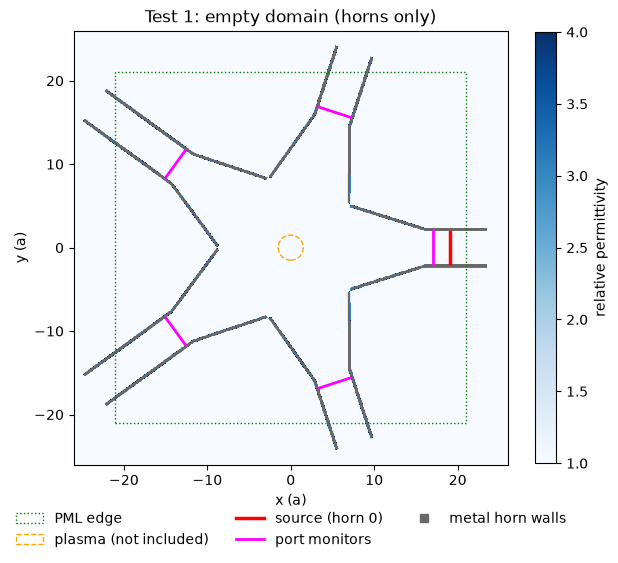

on time step 614 (time=15.35), 0.00652152 s/step
on time step 1228 (time=30.7), 0.00651475 s/step
on time step 1836 (time=45.9), 0.00658606 s/step
on time step 2411 (time=60.275), 0.00696026 s/step
on time step 2970 (time=74.25), 0.00716355 s/step
on time step 3511 (time=87.775), 0.007403 s/step
on time step 4065 (time=101.625), 0.0072213 s/step
on time step 4587 (time=114.675), 0.00767131 s/step
on time step 5144 (time=128.6), 0.00718757 s/step
on time step 5700 (time=142.5), 0.00719894 s/step
on time step 6254 (time=156.35), 0.00722112 s/step
on time step 6824 (time=170.6), 0.00702658 s/step
on time step 7385 (time=184.625), 0.00714492 s/step
on time step 7939 (time=198.475), 0.00722683 s/step
on time step 8479 (time=211.975), 0.00740825 s/step
on time step 9041 (time=226.025), 0.00712629 s/step
on time step 9594 (time=239.85), 0.00723638 s/step
on time step 10136 (time=253.4), 0.0073884 s/step
on time step 10703 (time=267.575), 0.00705897 s/step
on time step 11283 (time=282.075), 0.

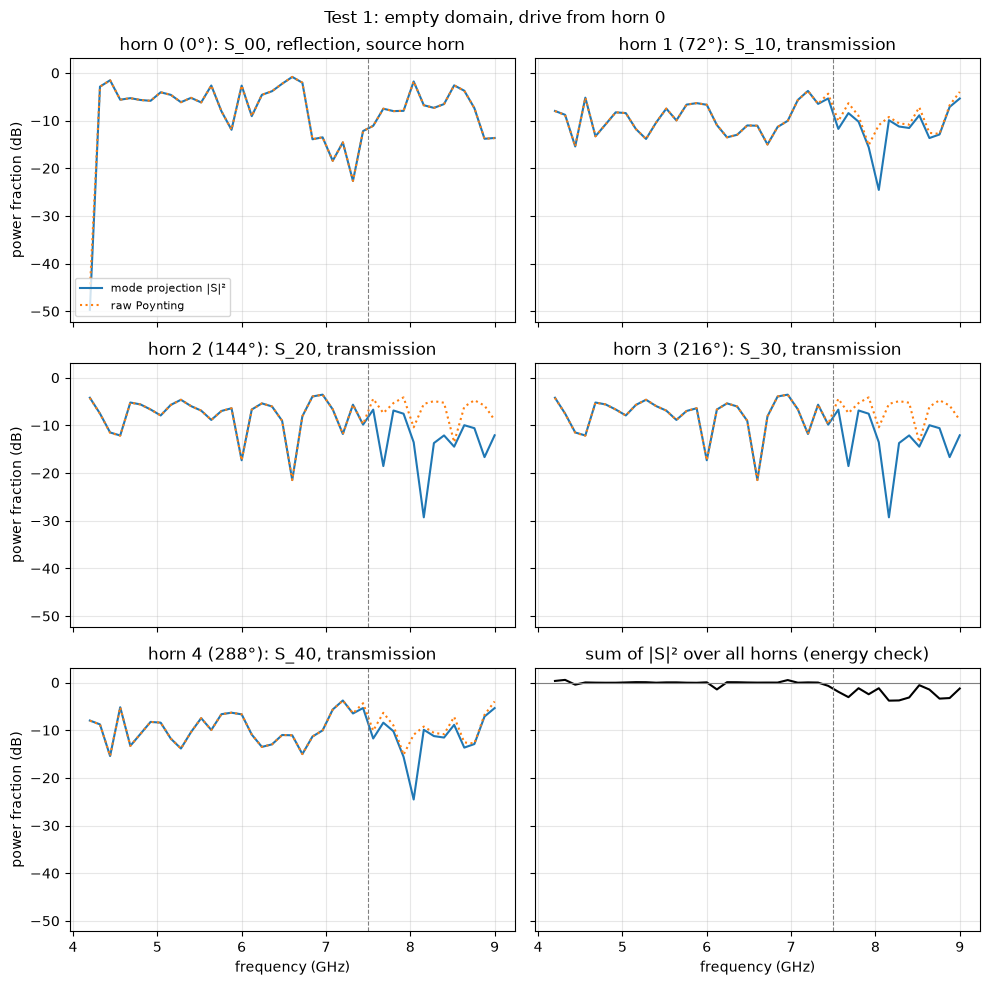

test1_empty, drive horn 0, 4.20-7.44 GHz:
  reflection |S_00|^2: max   -0.8 dB, median   -5.6 dB
  sum of |S|^2: -1.45 to +0.55 dB
  horn 0: mean |S|^2 = 0.296, max | |S|^2 - Poynting | = 0.000
  horn 1: mean |S|^2 = 0.140, max | |S|^2 - Poynting | = 0.076
  horn 2: mean |S|^2 = 0.209, max | |S|^2 - Poynting | = 0.004
  horn 3: mean |S|^2 = 0.209, max | |S|^2 - Poynting | = 0.004
  horn 4: mean |S|^2 = 0.140, max | |S|^2 - Poynting | = 0.076


In [6]:
## Test 1: empty domain (no scaffold, no plasma)

#Only the five horns, facing each other across vacuum. This isolates the horns, source and monitors.

#What to expect (guide Phase 1.4, check 1):
#- **Reflection** |S₀₀|² below about −20 dB: the flare matches the feed to free space.
#- **Sum** of |S|² near 0 dB: nothing absorbs, and the apertures cover the whole perimeter.
#- **Mirror symmetry**: horn 1 = horn 4 and horn 2 = horn 3.
#- **Smooth spectra**: no dielectric, so no cavity resonances.

test1 = build_case(k_src=0, scaffold_eps=None, plasma=None)
plot_geometry(test1, "Test 1: empty domain (horns only)")

res1 = run_case(test1, "test1_empty") #slow
plot_S(res1, "Test 1: empty domain, drive from horn 0")
summarize(res1)